In [3]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn import set_config; set_config(display='diagram')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectPercentile, VarianceThreshold, SelectFromModel, mutual_info_classif

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [4]:
from src.getdata_utils import load_data, split_data

In [5]:
filepath="../data/bank-full.csv"
df = pd.read_csv(filepath, sep=';', header=0)
df[df['y'] == 'yes'].head(50)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
83,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
86,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
87,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
129,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
168,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
270,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
388,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
390,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
446,39,technician,single,unknown,no,45248,yes,no,unknown,6,may,1623,1,-1,0,unknown,yes
457,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes


Shapes -> Train: (28934, 15), Val: (7234, 15), Test: (9043, 15)
CV ROC-AUC scores: [0.802 0.801 0.798 0.795 0.798]
Mean CV ROC-AUC: 0.799
Validation ROC-AUC: 0.806
Test ROC-AUC: 0.806

Top (original-column) permutation importances:
      feature  importance_mean  importance_std
10    housing         0.013093        0.000948
14   poutcome         0.010782        0.000959
9     default         0.008150        0.001137
8   education         0.003605        0.000658
12    contact         0.003163        0.000696
11       loan         0.001526        0.000404
6         job         0.001051        0.000675
5    previous         0.000885        0.000685
0         age         0.000863        0.000613
1     balance         0.000542        0.000365
7     marital         0.000453        0.000503
13      month         0.000420        0.000352
2         day         0.000365        0.000810
3    campaign         0.000254        0.000380
4       pdays         0.000000        0.000000


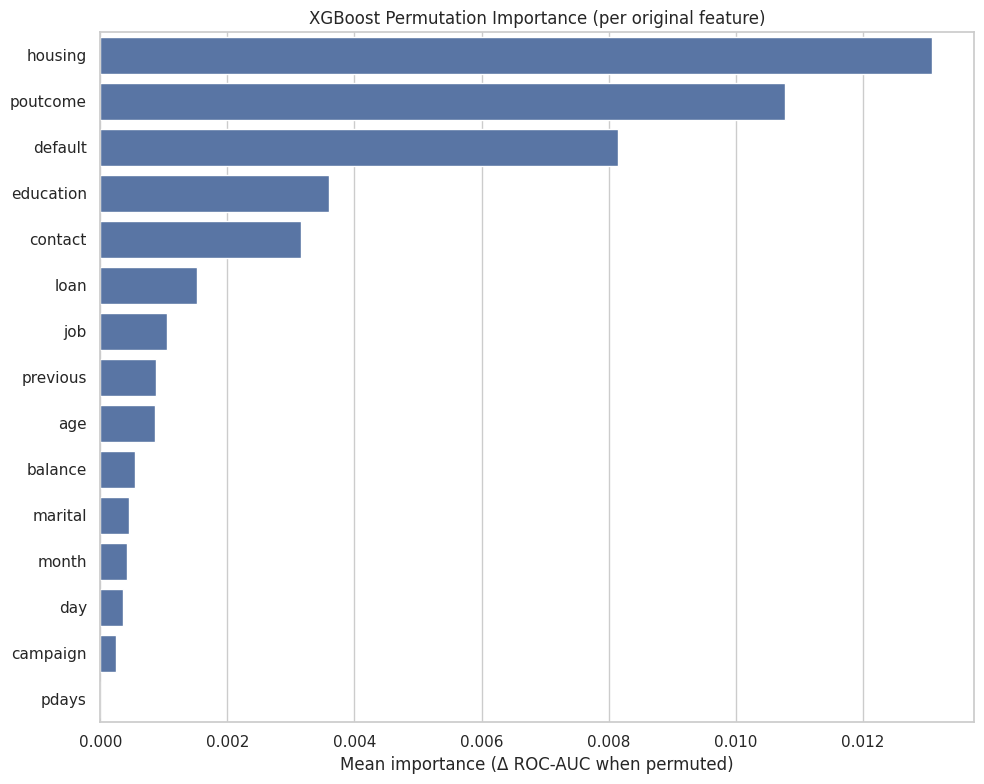

In [8]:
# =========================
# 1) Imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

# =========================
# 2) Data prep
# =========================
# df must be your original bank marketing dataframe with 'y' as 'yes'/'no'
# Example: df = pd.read_csv("bank.csv")

# --- Remove duration (leakage) if present
if "duration" in df.columns:
    df = df.drop(columns=["duration"])

# --- Encode target
df["y_binary"] = df["y"].map({"no": 0, "yes": 1})
X = df.drop(columns=["y", "y_binary"])
y = df["y_binary"]

# --- Identify feature types
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

# =========================
# 3) Train / Val / Test split
# =========================
# First: hold out test set (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Second: split train/val (e.g., 20% of trainval => 16% overall val)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=42
)

print(f"Shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# =========================
# 4) Preprocessor & Model
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop",
)

xgb = XGBClassifier(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
    tree_method="hist",
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb),
])

# =========================
# 5) Cross-Validation (on Train+Val)
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    pipeline, X_trainval, y_trainval,
    cv=cv, scoring="roc_auc", n_jobs=-1
)
print("CV ROC-AUC scores:", np.round(cv_scores, 3))
print("Mean CV ROC-AUC:", float(np.mean(cv_scores)).__round__(3))

# =========================
# 6) Fit on Train, evaluate on Val & Test
# =========================
pipeline.fit(X_train, y_train)

# Val AUC
val_proba = pipeline.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_proba)
print("Validation ROC-AUC:", round(val_auc, 3))

# Test AUC
test_proba = pipeline.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)
print("Test ROC-AUC:", round(test_auc, 3))

# =========================
# 7) Permutation Importance (per ORIGINAL feature) on Test set
# =========================
orig_features = num_features + cat_features

perm = permutation_importance(
    pipeline, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": orig_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop (original-column) permutation importances:")
print(perm_df.head(20))

# =========================
# 8) Plot Top 20 features
# =========================
plt.figure(figsize=(10, 8))
sns.barplot(data=perm_df.head(20), x="importance_mean", y="feature")
plt.title("XGBoost Permutation Importance (per original feature)")
plt.xlabel("Mean importance (Δ ROC-AUC when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# =========================
# (Optional) Granular per one-hot feature importances
# =========================
# If you later want one-hot-level detail, uncomment below:

# fitted_pre = pipeline.named_steps["preprocessor"]
# fitted_clf = pipeline.named_steps["classifier"]
# ohe = fitted_pre.named_transformers_["cat"]
# ohe_names = ohe.get_feature_names_out(cat_features)
# transformed_feature_names = list(num_features) + list(ohe_names)
# X_test_trans = fitted_pre.transform(X_test)
# perm_trans = permutation_importance(
#     fitted_clf, X_test_trans, y_test,
#     n_repeats=10, random_state=42, n_jobs=-1
# )
# perm_trans_df = pd.DataFrame({
#     "feature": transformed_feature_names,
#     "importance_mean": perm_trans.importances_mean,
#     "importance_std": perm_trans.importances_std
# }).sort_values("importance_mean", ascending=False)
# print("\nTop (one-hot) permutation importances:")
# print(perm_trans_df.head(25))
# plt.figure(figsize=(10, 10))
# sns.barplot(data=perm_trans_df.head(25), x="importance_mean", y="feature")
# plt.title("Permutation Importance (one-hot / transformed features)")
# plt.xlabel("Mean importance (Δ ROC-AUC)")
# plt.ylabel("")
# plt.tight_layout()
# plt.show()


Numeric features: ['day', 'campaign', 'previous', 'was_prev_contacted']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'balance_bin', 'age_bin']
Shapes -> Train: (28934, 15), Val: (7234, 15), Test: (9043, 15)
CV ROC-AUC scores: [0.8   0.807 0.796 0.797 0.797]
Mean CV ROC-AUC: 0.799
Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.02, 'clf__max_depth': 7, 'clf__n_estimators': 500, 'clf__subsample': 0.8}
Best CV ROC-AUC (GridSearch): 0.797
Validation ROC-AUC: 0.809
Test ROC-AUC: 0.807

Top permutation importances (per original/engineered feature):
               feature  importance_mean  importance_std
8              housing         0.015471        0.001708
11               month         0.015083        0.001095
7              default         0.010616        0.001210
6            education         0.005164        0.000755
4                

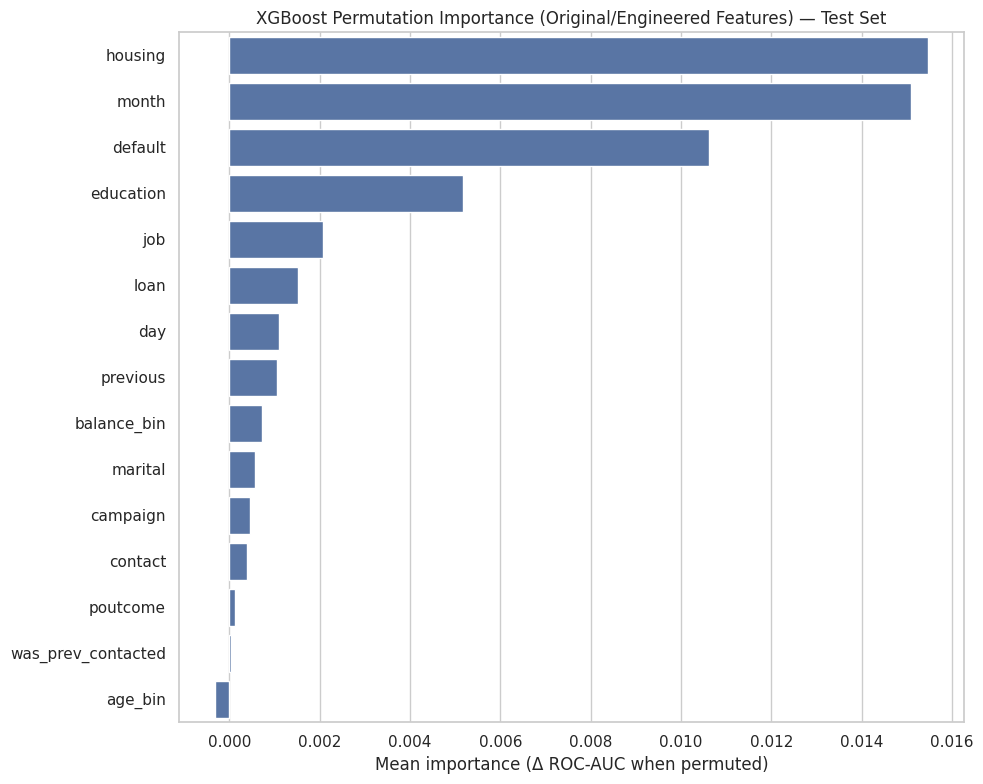

In [9]:
# =========================
# 0) Imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

# =========================
# 1) Start from original df
# =========================
# Expect df to be defined and contain 'y' in {'yes','no'}
df2 = df.copy()

# --- Remove duration (target leakage)
if "duration" in df2.columns:
    df2 = df2.drop(columns=["duration"])

# =========================
# 2) Feature engineering
# =========================
# a) pdays -> was_prev_contacted (binary), then drop pdays
if "pdays" in df2.columns:
    df2["was_prev_contacted"] = (df2["pdays"] != -1).astype(int)
    df2 = df2.drop(columns=["pdays"])

# b) balance -> quantile buckets (as categorical labels), then drop raw balance
if "balance" in df2.columns:
    # qcut can error when many ties; duplicates='drop' avoids that
    q = pd.qcut(df2["balance"], q=5, duplicates="drop")
    df2["balance_bin"] = q.astype(str)  # make explicitly categorical/text
    df2 = df2.drop(columns=["balance"])

# c) age -> fixed life-stage buckets (categorical), then drop raw age
if "age" in df2.columns:
    df2["age_bin"] = pd.cut(
        df2["age"],
        bins=[17, 30, 40, 50, 60, 120],
        labels=["18-30", "31-40", "41-50", "51-60", "60+"],
        right=True,
        include_lowest=True,
    ).astype(str)
    df2 = df2.drop(columns=["age"])

# =========================
# 3) Target + features
# =========================
df2["y_binary"] = df2["y"].map({"no": 0, "yes": 1})
X = df2.drop(columns=["y", "y_binary"])
y = df2["y_binary"].astype(int)

# Identify numeric vs categorical after engineering
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

# =========================
# 4) Train / Val / Test split
# =========================
# Hold-out Test (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
# From Train+Val, carve out Validation (20% of Train+Val ≈ 16% overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=42
)
print(f"Shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# =========================
# 5) Preprocessing & Base model
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop",
)

xgb_base = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
    tree_method="hist",
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", xgb_base),
])

# =========================
# 6) Cross-Validation on Train+Val
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    pipe, X_trainval, y_trainval, cv=cv, scoring="roc_auc", n_jobs=-1
)
print("CV ROC-AUC scores:", np.round(cv_scores, 3))
print("Mean CV ROC-AUC:", float(np.mean(cv_scores)).__round__(3))

# =========================
# 7) Hyperparameter search (GridSearchCV) on Train
# =========================
param_grid = {
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.02, 0.05, 0.1],
    "clf__n_estimators": [300, 500, 800],
    "clf__subsample": [0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.8, 0.9, 1.0],
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV ROC-AUC (GridSearch):", round(grid.best_score_, 3))

best_pipe = grid.best_estimator_

# =========================
# 8) Evaluate on Val & Test
# =========================
# Validation
val_proba = best_pipe.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_proba)
print("Validation ROC-AUC:", round(val_auc, 3))

# Test
test_proba = best_pipe.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)
print("Test ROC-AUC:", round(test_auc, 3))

# =========================
# 9) Permutation Importance (per engineered/original column) on Test
# =========================
orig_feats_for_perm = num_features + cat_features  # columns as seen by the pipeline before OHE

perm = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": orig_feats_for_perm,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop permutation importances (per original/engineered feature):")
print(perm_df.head(25))

# =========================
# 10) Plot top 20 features
# =========================
plt.figure(figsize=(10, 8))
sns.barplot(data=perm_df.head(20), x="importance_mean", y="feature")
plt.title("XGBoost Permutation Importance (Original/Engineered Features) — Test Set")
plt.xlabel("Mean importance (Δ ROC-AUC when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# =========================
# (Optional) Granular importances per one-hot feature
# =========================
# fitted_pre = best_pipe.named_steps["preprocessor"]
# fitted_clf = best_pipe.named_steps["clf"]
# ohe = fitted_pre.named_transformers_["cat"]
# ohe_names = ohe.get_feature_names_out(cat_features)
# transformed_feature_names = list(num_features) + list(ohe_names)
# X_test_trans = fitted_pre.transform(X_test)
# perm_trans = permutation_importance(
#     fitted_clf, X_test_trans, y_test,
#     n_repeats=10, random_state=42, n_jobs=-1
# )
# perm_trans_df = pd.DataFrame({
#     "feature": transformed_feature_names,
#     "importance_mean": perm_trans.importances_mean,
#     "importance_std": perm_trans.importances_std
# }).sort_values("importance_mean", ascending=False)
# print("\nTop one-hot permutation importances:")
# print(perm_trans_df.head(25))
# plt.figure(figsize=(10, 10))
# sns.barplot(data=perm_trans_df.head(25), x="importance_mean", y="feature")
# plt.title("Permutation Importance (One-Hot Features) — Test Set")
# plt.xlabel("Mean importance (Δ ROC-AUC)")
# plt.ylabel("")
# plt.tight_layout()
# plt.show()


Numeric features: ['age', 'day', 'campaign', 'previous', 'was_prev_contacted', 'balance_slog']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Shapes -> Train: (28934, 15), Val: (7234, 15), Test: (9043, 15)
CV ROC-AUC scores: [0.798 0.803 0.794 0.797 0.798]
Mean CV ROC-AUC: 0.798
Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.02, 'clf__max_depth': 7, 'clf__n_estimators': 300, 'clf__subsample': 0.8}
Best CV ROC-AUC (GridSearch): 0.796
Validation ROC-AUC: 0.805
Test ROC-AUC: 0.808

Top permutation importances (per original/engineered feature):
               feature  importance_mean  importance_std
12             contact         0.013292        0.001092
9              default         0.007033        0.000562
7              marital         0.003306        0.000655
8            education         0.003306        0.000972
11                lo

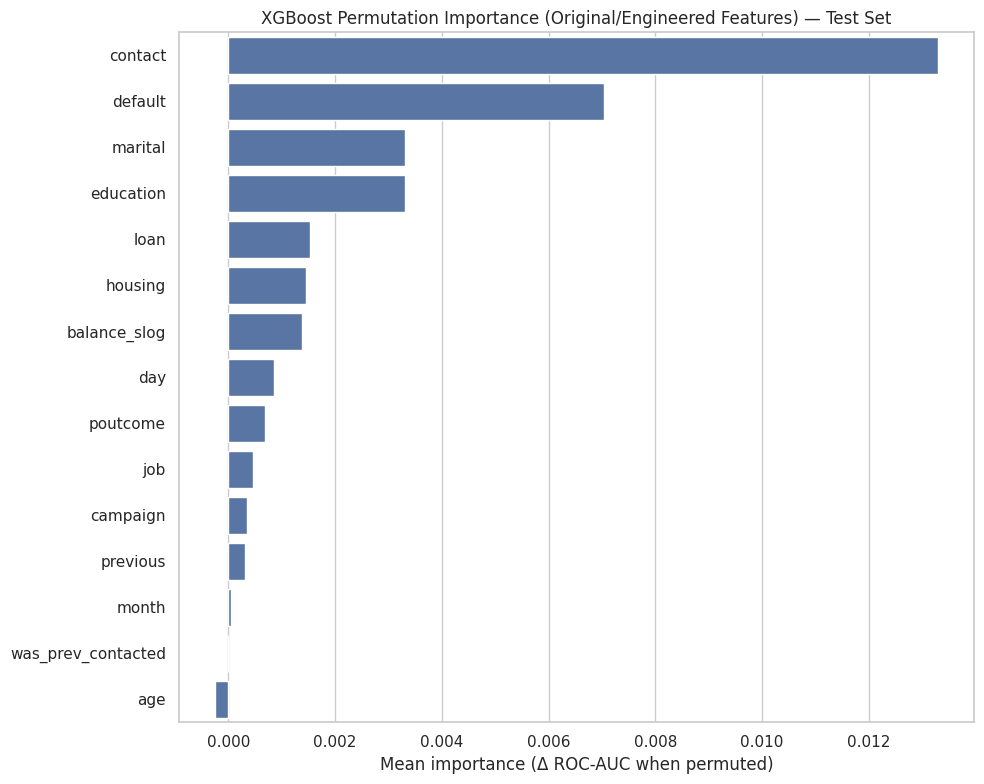

In [10]:
# =========================
# 0) Imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

# =========================
# 1) Start from original df
# =========================
# Expect df to be defined and contain 'y' in {'yes','no'}
df2 = df.copy()

# --- Remove duration (target leakage)
if "duration" in df2.columns:
    df2 = df2.drop(columns=["duration"])

# =========================
# 2) Feature engineering
# =========================
# a) pdays -> was_prev_contacted (binary), then drop pdays
if "pdays" in df2.columns:
    df2["was_prev_contacted"] = (df2["pdays"] != -1).astype(int)
    df2 = df2.drop(columns=["pdays"])

# b) balance -> signed log transform (handles negatives), then drop raw balance
#    balance_slog = sign(balance) * log1p(|balance|)
if "balance" in df2.columns:
    df2["balance_slog"] = np.sign(df2["balance"]) * np.log1p(np.abs(df2["balance"]))
    df2 = df2.drop(columns=["balance"])

# c) KEEP age as continuous (no binning)

# =========================
# 3) Target + features
# =========================
df2["y_binary"] = df2["y"].map({"no": 0, "yes": 1}).astype(int)
X = df2.drop(columns=["y", "y_binary"])
y = df2["y_binary"]

# Identify numeric vs categorical after engineering
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

# =========================
# 4) Train / Val / Test split
# =========================
# Hold-out Test (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
# From Train+Val, carve out Validation (20% of Train+Val ≈ 16% overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=42
)
print(f"Shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# =========================
# 5) Preprocessing & Base model
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop",
)

xgb_base = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
    tree_method="hist",
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", xgb_base),
])

# =========================
# 6) Cross-Validation on Train+Val
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    pipe, X_trainval, y_trainval, cv=cv, scoring="roc_auc", n_jobs=-1
)
print("CV ROC-AUC scores:", np.round(cv_scores, 3))
print("Mean CV ROC-AUC:", float(np.mean(cv_scores)).__round__(3))

# =========================
# 7) Hyperparameter search (GridSearchCV) on Train
# =========================
param_grid = {
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.02, 0.05, 0.1],
    "clf__n_estimators": [300, 500, 800],
    "clf__subsample": [0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.8, 0.9, 1.0],
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV ROC-AUC (GridSearch):", round(grid.best_score_, 3))

best_pipe = grid.best_estimator_

# =========================
# 8) Evaluate on Val & Test
# =========================
# Validation
val_proba = best_pipe.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_proba)
print("Validation ROC-AUC:", round(val_auc, 3))

# Test
test_proba = best_pipe.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)
print("Test ROC-AUC:", round(test_auc, 3))

# =========================
# 9) Permutation Importance (per original/engineered feature) on Test
# =========================
orig_feats_for_perm = num_features + cat_features  # columns as seen by the pipeline before OHE

perm = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": orig_feats_for_perm,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop permutation importances (per original/engineered feature):")
print(perm_df.head(25))

# =========================
# 10) Plot top 20 features
# =========================
plt.figure(figsize=(10, 8))
sns.barplot(data=perm_df.head(20), x="importance_mean", y="feature")
plt.title("XGBoost Permutation Importance (Original/Engineered Features) — Test Set")
plt.xlabel("Mean importance (Δ ROC-AUC when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [11]:
pip install shap


  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 996.4/996.4 kB 8.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 30.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 42.4 MB/s  0:00:01m0:00:0100:01
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]5/6 [shap]]te]
Note: you may need to restart the kernel to use updated packages.


In [12]:
import shap
import matplotlib.pyplot as plt

# 1) Get trained XGB model from pipeline
xgb_model = grid_search.best_estimator_.named_steps["clf"]

# 2) Transform data (preprocessed numeric + categorical encoding)
X_val_transformed = grid_search.best_estimator_.named_steps["preprocessor"].transform(X_val)

# 3) Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# 4) Compute SHAP values for validation set
shap_values = explainer.shap_values(X_val_transformed)


/home/farah/.pyenv/versions/3.10.6/envs/lewagon_cust_targeting/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'grid_search' is not defined

Note: If you see an IProgress/tqdm warning, you can install ipywidgets to remove it.


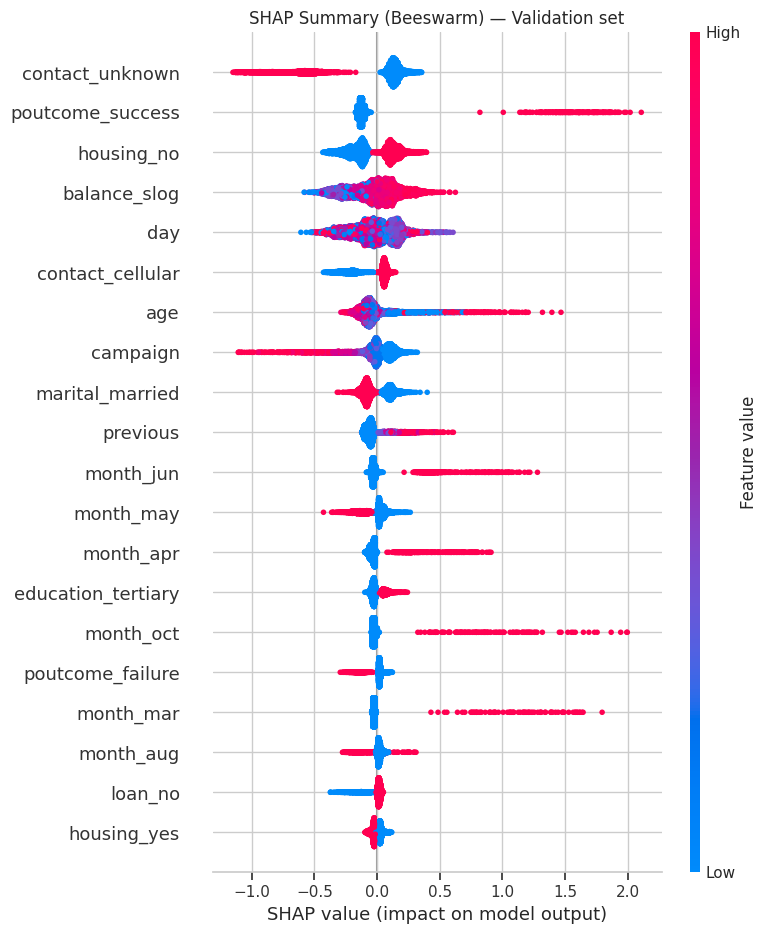

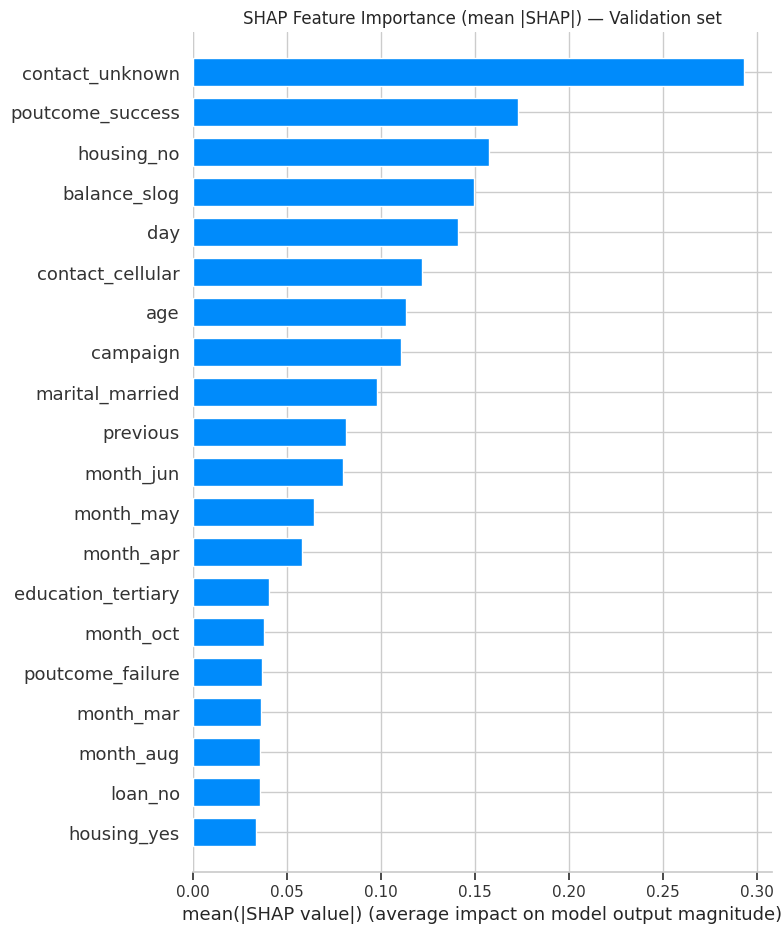


Top original features by aggregated mean |SHAP|:
          feature_orig  mean_abs_shap
11               month       0.436347
3              contact       0.418874
12            poutcome       0.226293
7              housing       0.191186
1         balance_slog       0.149632
4                  day       0.141102
10             marital       0.134248
0                  age       0.113074
2             campaign       0.110341
13            previous       0.081367
6            education       0.065486
8                  job       0.058523
9                 loan       0.046214
14  was_prev_contacted       0.017971
5              default       0.000584


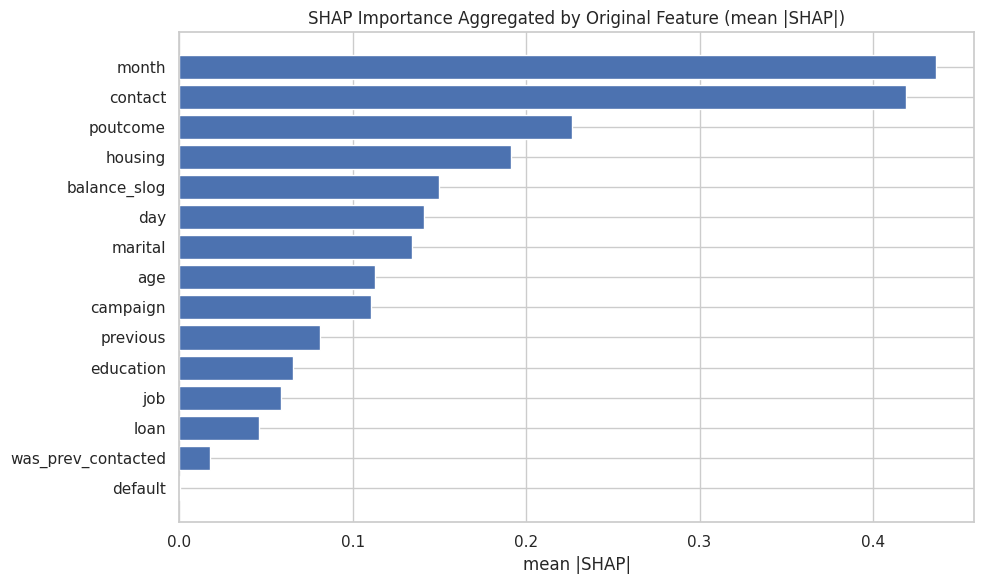

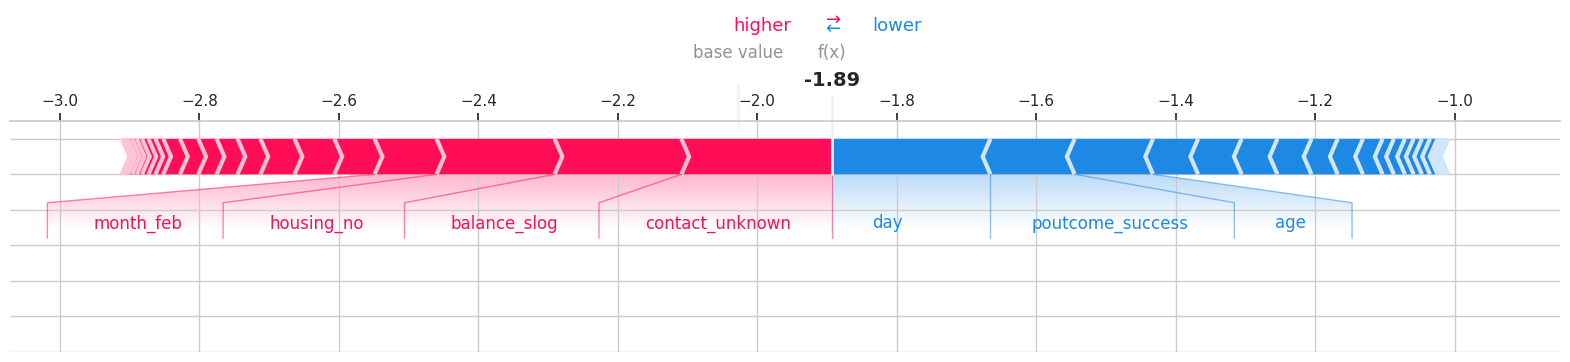

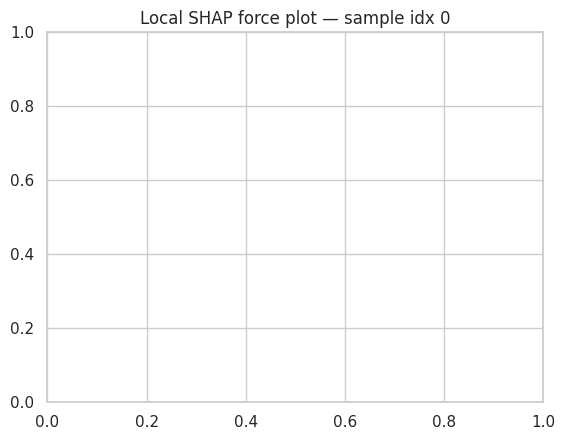

In [13]:
# ==== SHAP analysis for your tuned pipeline ====
# If needed: pip install shap ipywidgets
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Silence the Jupyter tqdm warning (optional)
print("Note: If you see an IProgress/tqdm warning, you can install ipywidgets to remove it.")

# 1) Pull the trained XGB model and preprocessor from your BEST pipeline
xgb_model = best_pipe.named_steps["clf"]
preproc   = best_pipe.named_steps["preprocessor"]

# 2) Transform the validation set and get transformed feature names
X_val_trans = preproc.transform(X_val)

# OneHotEncoder names
ohe = preproc.named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(cat_features)  # e.g., ['job_admin.', 'job_blue-collar', ...]

# Final transformed feature name list (numeric first, then one-hot categorical)
feat_names_trans = list(num_features) + list(ohe_names)

# 3) Build a TreeExplainer and compute SHAP values
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val_trans)  # array [n_samples, n_features]
# (For XGBoost binary classification, TreeExplainer returns shap values for the positive class.)

# 4) Global summary plots
# Beeswarm (impact + direction)
shap.summary_plot(shap_values, X_val_trans, feature_names=feat_names_trans, show=False)
plt.title("SHAP Summary (Beeswarm) — Validation set")
plt.tight_layout()
plt.show()

# Bar (global importance by mean |SHAP|)
shap.summary_plot(shap_values, X_val_trans, feature_names=feat_names_trans, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (mean |SHAP|) — Validation set")
plt.tight_layout()
plt.show()

# 5) Optional: Aggregate SHAP back to ORIGINAL features (sum |SHAP| across one-hot levels)
# Mean absolute SHAP per transformed feature
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)  # length = n_transformed_features
shap_df = pd.DataFrame({"feature_trans": feat_names_trans, "mean_abs_shap": mean_abs_shap})

def parent_feature_name(trans_name: str) -> str:
    """
    Map a transformed (one-hot) name like 'job_admin.' -> 'job'.
    Numeric features are already original names, so return as-is.
    """
    # If it's one of the numeric features, keep it
    if trans_name in num_features:
        return trans_name
    # OneHotEncoder naming convention: '<orig>_<category>'
    # Split only on the first underscore
    return trans_name.split("_", 1)[0]

shap_df["feature_orig"] = shap_df["feature_trans"].apply(parent_feature_name)

# Sum contributions across all one-hot levels for the same original feature
shap_agg = (
    shap_df.groupby("feature_orig", as_index=False)["mean_abs_shap"]
           .sum()
           .sort_values("mean_abs_shap", ascending=False)
)

print("\nTop original features by aggregated mean |SHAP|:")
print(shap_agg.head(20))

# Plot aggregated top 15
plt.figure(figsize=(10, 6))
topn = shap_agg.head(15)
plt.barh(topn["feature_orig"][::-1], topn["mean_abs_shap"][::-1])
plt.title("SHAP Importance Aggregated by Original Feature (mean |SHAP|)")
plt.xlabel("mean |SHAP|")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 6) Optional: Local explanation for a single example (pick an index)
idx = 0  # change as needed
shap.force_plot(
    explainer.expected_value, 
    shap_values[idx, :], 
    matplotlib=True, 
    feature_names=feat_names_trans
)
plt.title(f"Local SHAP force plot — sample idx {idx}")
plt.show()
